In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date
import numpy as np
import datetime
from datetime import datetime
import matplotlib.patches as mpatches
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

In [51]:
tissues = ["kidney", "liver",  "lung", "heart", 
           "brainFC", "brainHip", "brainCB",
           "BAT", "testis",
            "muscle", "colon", "spleen"] 

len(tissues)

12

In [52]:
histone_mark = "H3K9me3"

df_meta_list = []
for tissue in tissues:
        path = f"~/projects/paired_seq_tag/results/{tissue}-merged/dna-qc/{histone_mark}_mouse_metadata_stat.csv"
        df_tmp = pd.read_csv(path)
        df_tmp["tissue"] = tissue  # 添加 tissue 信息列
        df_tmp["histone_mark"] = histone_mark  # 添加组蛋白修饰类型
        df_tmp["tissue_ct"] = tissue + '-' + df_tmp["cell_type"]
        df_meta_list.append(df_tmp)
df_meta = pd.concat(df_meta_list, ignore_index=True)

# Within each tissue + cell_type group, if the same mouse appears multiple times,
# append "-2", "-3", etc. to duplicates

df_meta = df_meta.sort_values(by=["tissue", "cell_type", "mouse"]).reset_index(drop=True)
def rename_duplicates(group):
    counts = {}
    new_mouse = []
    for m in group["mouse"]:
        counts[m] = counts.get(m, 0) + 1
        if counts[m] == 1:
            new_mouse.append(m)
        else:
            new_mouse.append(f"{m}-{counts[m]}")
    group["mouse"] = new_mouse
    return group
df_meta = df_meta.groupby(["tissue", "cell_type", "histone_mark"], group_keys=False).apply(rename_duplicates)
df_meta['tissue'] = df_meta['tissue_ct'].str.split('-').str[0]

df_meta.shape

(807, 8)

In [53]:
total_reads = (
    df_meta.groupby(["tissue", "tissue_ct"])["total_reads"]
    .sum()
    .reset_index()
)
total_reads.head()

,tissue,tissue_ct,total_reads
0,BAT,BAT-ASPC,3183616
1,BAT,BAT-Adipocyte,10208019
2,BAT,BAT-B_cell,1285046
3,BAT,BAT-Brown_adipocyte,47236188
4,BAT,BAT-MSC,312290


In [54]:
total_reads.shape

(193, 3)

In [55]:
import pandas as pd
import glob
import os

# 1. 找所有 bed 文件
files = glob.glob("/storage/zhangyanxiaoLab/qihongjian/github/zhanglab-code/projects/paired_seq_tag/code/machine-experiments/DNA/peaks/data/*_H3K9me3.bed")

res = []

for f in files:
    # 2. 读取bed（无header）
    if f.startswith("/storage/zhangyanxiaoLab/qihongjian/github/zhanglab-code/projects/paired_seq_tag/code/machine-experiments/DNA/peaks/data/DNA."): continue
    df = pd.read_csv(f, sep="\t", header=None)
    df.columns = ["chr", "start", "end", "score"]

    # 3. 计算 peak length
    df["length"] = df["end"] - df["start"]

    # 4. 统计
    npeaks = df.shape[0]
    total_length = df["length"].sum()

    # 5. 解析文件名
    basename = os.path.basename(f).replace("_H3K9me3.bed", "")
    parts = basename.split(".")

    tissue = parts[0]
    ct = ".".join(parts[1:])   # 防止 cell type 里还有点

    tissue_ct = f"{tissue}-{ct}"

    # 6. 存结果
    res.append({
        "tissue_ct": tissue_ct,
        "npeaks": npeaks,
        "peak_length": total_length
    })

# 7. 汇总 dataframe
peak_df = pd.DataFrame(res)

In [56]:
df = pd.merge(total_reads, peak_df, on="tissue_ct")
df.shape

(193, 5)

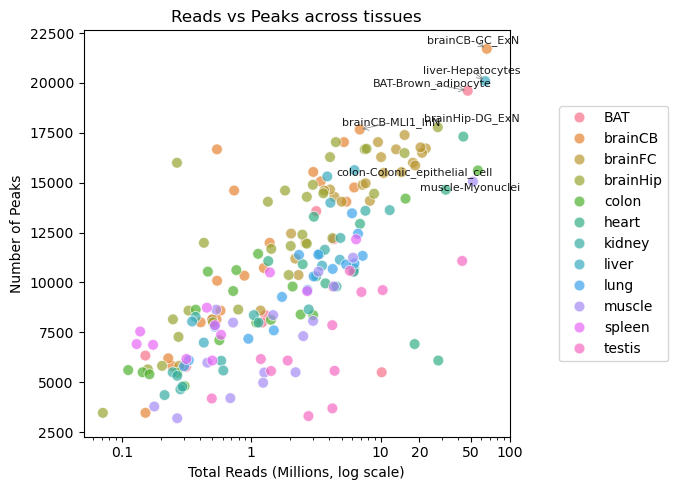

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# --------------------------
# 假设你的数据在 df
# --------------------------
# df 列: tissue, tissue_ct, total_reads, npeaks, peak_length

# 转换 reads 为百万单位
df["total_reads_M"] = df["total_reads"] / 1e6

plt.figure(figsize=(7,5))

# scatter plot
sns.scatterplot(
    data=df,
    x="total_reads_M",
    y="npeaks",
    hue="tissue",
    s=60,
    alpha=0.7
)

# log scale x
plt.xscale("log")

# 自定义 xticks
ticks = [0.1, 1, 10, 20, 50, 100]
plt.xticks(ticks, labels=[str(t) for t in ticks])

plt.xlabel("Total Reads (Millions, log scale)")
plt.ylabel("Number of Peaks")
plt.title("Reads vs Peaks across tissues")

# legend 右下角
# legend 右下角
plt.legend(
    loc='center left',       # legend 的锚点位置在左中
    bbox_to_anchor=(1.1, 0.5)  # 图外右侧，y 居中
)


# --------------------------
# 标注 top peaks & top reads
# --------------------------
top_peaks = df.nlargest(5, "npeaks")
top_reads = df.nlargest(5, "total_reads_M")

# 合并去重
top_df = pd.concat([top_peaks, top_reads]).drop_duplicates()

# 使用 adjustText
texts = []
for _, row in top_df.iterrows():
    texts.append(
        plt.text(
            row["total_reads_M"],
            row["npeaks"],
            row["tissue_ct"],
            fontsize=8,
            alpha=0.9
        )
    )

# 自动调整文字避免重叠
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5),
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2)
)

plt.tight_layout()
plt.show()